In [55]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import pearsonr, spearmanr, linregress

# 한글 폰트 설정 - Windows
plt.rcParams["font.family"] = "Malgun Gothic"

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False


## 가설검정 순서
1. 가설 설정 
    - 대립가설 : 밝히고자 하는 가설
    - 귀무가설 : 대립가설의 반대 / 보통 차이가 없다 같은 내용을 담음. 
2. 검정 방법 선택
3. 유의수준 결정
4. 검정통계량과 p-value
5. 결론/결과해석
    - p-value < 유의 수준 : 귀무가설 기각 / 대립가설 채택
    - p-value >= 유의 수준 : 귀무가설 채택/ 대립가설 기각

# 1. 가설: 공시지가 상승률이 높은 지역일수록 프랜차이즈 침투율이 높은것이다.

In [34]:
main = pd.read_csv("../data/행정동_분기_마스터(최종).csv", encoding="utf-8-sig") 
legal = pd.read_csv("../data/법정동_연도_마스터.csv", encoding="utf-8-sig")
print(main.shape) 
print(legal.shape) 
main.head()

(600, 43)
(129, 17)


,base_quarter,year,quarter,adm_dong_cd,adm_dong_nm,gu,floating_pop,purpose_0_ratio,purpose_1_ratio,purpose_2_ratio,...,close_cnt,open_rate,close_rate,franchise_ratio,industry_diversity_H,survival_rate_1y,bus_board_cnt,bus_alight_cnt,전입_소득수준_가중평균,전출_소득수준_가중평균
0,2023Q1,2023,1,41131510,신흥1동,수정구,781803.43,0.459359,0.073425,0.002433,...,77.0,1.687408,1.624130,4.893482,3.511952,NaN,383269.0,368664.0,3188.370885,3252.77624
1,2023Q2,2023,2,41131510,신흥1동,수정구,808998.65,0.483425,0.076062,0.004197,...,53.0,0.989283,1.092333,4.843364,3.494871,NaN,405702.0,386649.0,3188.370885,3252.77624
2,2023Q3,2023,3,41131510,신흥1동,수정구,807881.77,0.487323,0.074089,0.003615,...,112.0,1.515470,2.357398,5.156809,3.500230,NaN,416726.0,400858.0,3188.370885,3252.77624
3,2023Q4,2023,4,41131510,신흥1동,수정구,860145.94,0.482244,0.072668,0.004490,...,57.0,0.888889,1.206349,5.164021,3.480380,NaN,423823.0,406845.0,3188.370885,3252.77624
4,2024Q1,2024,1,41131510,신흥1동,수정구,779105.37,0.493551,0.069158,0.003135,...,61.0,1.198486,1.282590,5.277544,3.488654,72.534143,401542.0,392547.0,3188.370885,3252.77624


In [35]:
print("main 컬럼")
print(main.columns.tolist())

print("\nlegal 컬럼")
print(legal.columns.tolist())

main 컬럼
['base_quarter', 'year', 'quarter', 'adm_dong_cd', 'adm_dong_nm', 'gu', 'floating_pop', 'purpose_0_ratio', 'purpose_1_ratio', 'purpose_2_ratio', 'purpose_3_ratio', 'purpose_4_ratio', 'purpose_5_ratio', 'purpose_6_ratio', 'external_inflow', 'stay_time_weighted', 'stay_time_cnt', 'transport_total_cnt', 'transport_0_ratio', 'transport_1_ratio', 'transport_2_ratio', 'transport_3_ratio', 'transport_4_ratio', 'transport_5_ratio', 'transport_6_ratio', 'transport_7_ratio', 'sales_amt', 'sales_cnt', 'avg_ticket', 'new_corp_cnt', 'store_mer_cnt', 'franchise_cnt', 'open_cnt', 'close_cnt', 'open_rate', 'close_rate', 'franchise_ratio', 'industry_diversity_H', 'survival_rate_1y', 'bus_board_cnt', 'bus_alight_cnt', '전입_소득수준_가중평균', '전출_소득수준_가중평균']

legal 컬럼
['legal_dong_nm', 'legal_dong_full_nm', 'gu', 'year', 'land_price_median', 'land_price_growth', 'land_price_growth_yoy', 'land_parcel_cnt', 'land_parcel_count_ok', 'land_price_2023_median', 'land_price_2024_median', 'land_price_2025_median'

In [36]:
# 가설검정 반복하기위한 함수 코드
def one_sided_positive_p(r, p_two):
    """
    양의 방향 단측검정 p-value 계산
    H1: x가 커질수록 y도 커진다
    """
    if r > 0:
        return p_two / 2
    elif r < 0:
        return 1 - (p_two / 2)
    else:
        return 0.5


def corr_test(df, x_col, y_col, hypothesis, alternative="two-sided", min_n=10):
    """
    Pearson / Spearman 상관검정 함수
    alternative:
        "greater" = 양의 관계 단측검정
        "two-sided" = 양측검정
    """
    temp = df[[x_col, y_col]].dropna()
    n = len(temp)

    if n < min_n:
        return {
            "가설": hypothesis,
            "X변수": x_col,
            "Y변수": y_col,
            "표본수": n,
            "Pearson_r": None,
            "Pearson_p": None,
            "Spearman_rho": None,
            "Spearman_p": None,
            "판정": "표본 부족"
        }

    x = temp[x_col]
    y = temp[y_col]

    pearson_r, pearson_p_two = pearsonr(x, y)
    spearman_rho, spearman_p_two = spearmanr(x, y)

    if alternative == "greater":
        pearson_p = one_sided_positive_p(pearson_r, pearson_p_two)
        spearman_p = one_sided_positive_p(spearman_rho, spearman_p_two)
    else:
        pearson_p = pearson_p_two
        spearman_p = spearman_p_two

    if spearman_p < 0.05:
        decision = "유의함"
    elif spearman_p < 0.1:
        decision = "약한 경향"
    else:
        decision = "유의하지 않음"

    return {
        "가설": hypothesis,
        "X변수": x_col,
        "Y변수": y_col,
        "표본수": n,
        "Pearson_r": round(pearson_r, 4),
        "Pearson_p": round(pearson_p, 4),
        "Spearman_rho": round(spearman_rho, 4),
        "Spearman_p": round(spearman_p, 4),
        "판정": decision
    }

2. 가설 설정
- 귀무가설: 공시지가 상승률과 프랜차이즈 침투율은 상관관계가 없다.
- 대립가설: 공시지가 상승률과 프랜차이즈 침투율이 높으면 상관관계가 있다.

일단 행정동이랑 법정동 데이터가 main은 분기 단위이고, legal는 연도 단위이니 main을 연도 단위로 바꿔야됨

In [37]:
main["year"] = main["base_quarter"].str[:4].astype(int)

main_year = main.groupby(
    ["gu", "adm_dong_nm", "year"],
    as_index=False
).agg(
    franchise_ratio=("franchise_ratio", "mean"),
    franchise_cnt=("franchise_cnt", "mean")
)

display(main_year.head())
print(main_year.shape)

,gu,adm_dong_nm,year,franchise_ratio,franchise_cnt
0,분당구,구미1동,2023,4.928932,308.50
1,분당구,구미1동,2024,5.195820,330.00
2,분당구,구미1동,2025,4.811551,321.25
3,분당구,구미동,2023,7.499455,611.25
4,분당구,구미동,2024,7.915777,658.50


(150, 5)


In [38]:
# 행정동명 1동 2동을 법정동명에 맞추기
def make_legal_key(x):
    x = str(x)
    return re.sub(r"(.+)\d+동$", r"\1동", x)

main_year["legal_key"] = main_year["adm_dong_nm"].apply(make_legal_key)

display(main_year[["adm_dong_nm", "legal_key"]].drop_duplicates().head(30))

,adm_dong_nm,legal_key
0,구미1동,구미동
3,구미동,구미동
6,금곡동,금곡동
9,백현동,백현동
12,분당동,분당동
15,삼평동,삼평동
18,서현1동,서현동
21,서현2동,서현동
24,수내1동,수내동
27,수내2동,수내동


행정동데이터를 법정동명으로 매핑 완료 그래서 공시지가 데이터와 병합

In [39]:
h1_master = main_year.merge(
    legal[["gu", "legal_dong_nm", "year", "land_price_growth"]],
    left_on=["gu", "legal_key", "year"],
    right_on=["gu", "legal_dong_nm", "year"],
    how="inner"
)

print("병합 후 행 수:", len(h1_master))
display(h1_master.head())

병합 후 행 수: 147


,gu,adm_dong_nm,year,franchise_ratio,franchise_cnt,legal_key,legal_dong_nm,land_price_growth
0,분당구,구미1동,2023,4.928932,308.50,구미동,구미동,NaN
1,분당구,구미1동,2024,5.195820,330.00,구미동,구미동,2.669029
2,분당구,구미1동,2025,4.811551,321.25,구미동,구미동,3.018522
3,분당구,구미동,2023,7.499455,611.25,구미동,구미동,NaN
4,분당구,구미동,2024,7.915777,658.50,구미동,구미동,2.669029


In [40]:
# 가설검정에 쓸 수있는 분석 가능 행수 확인
h1_data = h1_master[[
    "gu",
    "adm_dong_nm",
    "legal_key",
    "legal_dong_nm",
    "year",
    "land_price_growth",
    "franchise_ratio"
]].dropna()

print("H1 분석 가능 행 수:", len(h1_data))
display(h1_data.head())

H1 분석 가능 행 수: 98


,gu,adm_dong_nm,legal_key,legal_dong_nm,year,land_price_growth,franchise_ratio
1,분당구,구미1동,구미동,구미동,2024,2.669029,5.195820
2,분당구,구미1동,구미동,구미동,2025,3.018522,4.811551
4,분당구,구미동,구미동,구미동,2024,2.669029,7.915777
5,분당구,구미동,구미동,구미동,2025,3.018522,7.579956
7,분당구,금곡동,금곡동,금곡동,2024,4.493319,5.580629


In [41]:
# 이제 상관관계 검정 실행
h1_result = corr_test(
    h1_data,
    x_col="land_price_growth",
    y_col="franchise_ratio",
    hypothesis="H1 공시지가 상승률이 높은 지역일수록 프랜차이즈 침투율이 높을 것이다",
    alternative="greater"
)

h1_result_df = pd.DataFrame([h1_result])
display(h1_result_df)

,가설,X변수,Y변수,표본수,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,판정
0,H1 공시지가 상승률이 높은 지역일수록 프랜차이즈 침투율이 높을 것이다,land_price_growth,franchise_ratio,98,0.3025,0.0012,0.256,0.0055,유의함


r은 직선관계 rho는 순위 관계

| 구분     | Pearson r                  | Spearman rho                |
| ------ | -------------------------- | --------------------------- |
| 보는 것   | 실제 값의 직선 관계                | 순위 관계                       |
| 관계 형태  | 선형 관계                      | 단조 관계                       |
| 이상치 영향 | 상대적으로 큼                    | 상대적으로 작음                    |
| 예시 질문  | 상승률이 커질수록 침투율이 직선적으로 증가하나? | 상승률 순위가 높은 지역이 침투율 순위도 높은가? |
| 네 결과   | r = 0.3025                 | rho = 0.2560                |


상관관계에 비해 p값은 작은데 이유는 상관관계가 없다고 가정했을 떄 지금같은 결과가 우연히 나올 가능성이 낮다는 뜻이다.
그래서 상관관계를 봤을때 0.30, 0.25로 귀무가설을 기각하고 두 변수사이에 통계적으로 약한 상관관계가 있다고 볼 수 있다.

# 2. 가설: 공시지가 상승률이 높은 지역일수록 상업용 부동산 거래량이 많을 것이다.

1. 가설 설정
- 귀무가설: 공시지가 상승률과 상업용 부동산 거래량은 상관관계가 없다.
- 대립가설: 공시지가 상승률이 높을수록 상업용 부동산 거래량도 많아지는 상관관계가 있다.

In [42]:
legal_q = pd.read_csv("../data/법정동_분기_마스터.csv", encoding="utf-8-sig")

print(legal_q.shape)
print(legal_q.columns.tolist())
display(legal_q.head())

(516, 17)
['legal_dong_nm', 'legal_dong_full_nm', 'gu', 'base_quarter', 'year', 'quarter', 'land_price_median', 'land_price_growth', 'land_price_growth_yoy', 'land_parcel_cnt', 'land_parcel_count_ok', 'land_growth_23_25_median', 'land_growth_cagr_23_25_median', 'land_growth_23_25_mean', 'transaction_cnt', 'transaction_amt_sum', 'transaction_amt_mean']


,legal_dong_nm,legal_dong_full_nm,gu,base_quarter,year,quarter,land_price_median,land_price_growth,land_price_growth_yoy,land_parcel_cnt,land_parcel_count_ok,land_growth_23_25_median,land_growth_cagr_23_25_median,land_growth_23_25_mean,transaction_cnt,transaction_amt_sum,transaction_amt_mean
0,갈현동,경기도 성남시 중원구 갈현동,중원구,2023Q1,2023,1,1760000.0,NaN,NaN,19,False,4.532415,2.241095,5.474931,0,0.0,NaN
1,갈현동,경기도 성남시 중원구 갈현동,중원구,2023Q2,2023,2,1760000.0,NaN,NaN,19,False,4.532415,2.241095,5.474931,0,0.0,NaN
2,갈현동,경기도 성남시 중원구 갈현동,중원구,2023Q3,2023,3,1760000.0,NaN,NaN,19,False,4.532415,2.241095,5.474931,0,0.0,NaN
3,갈현동,경기도 성남시 중원구 갈현동,중원구,2023Q4,2023,4,1760000.0,NaN,NaN,19,False,4.532415,2.241095,5.474931,0,0.0,NaN
4,갈현동,경기도 성남시 중원구 갈현동,중원구,2024Q1,2024,1,1775000.0,0.860585,0.860585,19,False,4.532415,2.241095,5.474931,0,0.0,NaN


확인결과 공시지가 상승률은 land_price_growth로 들고 와있으니 부동산 거래량의 transaction_cnt 데이터 불러오기

In [43]:
# 2번쨰 가설검정 분석 데이터셋 만들기
h2_data = legal_q[[
    "gu",
    "legal_dong_nm",
    "base_quarter",
    "year",
    "land_price_growth",
    "transaction_cnt"
]].dropna()

print("H2 분석 가능 행 수:", len(h2_data))
display(h2_data.head())

H2 분석 가능 행 수: 344


,gu,legal_dong_nm,base_quarter,year,land_price_growth,transaction_cnt
4,중원구,갈현동,2024Q1,2024,0.860585,0
5,중원구,갈현동,2024Q2,2024,0.860585,0
6,중원구,갈현동,2024Q3,2024,0.860585,0
7,중원구,갈현동,2024Q4,2024,0.860585,0
8,중원구,갈현동,2025Q1,2025,3.640501,0


In [44]:
h2_result = corr_test(
    h2_data,
    x_col="land_price_growth",
    y_col="transaction_cnt",
    hypothesis="H2 공시지가 상승률이 높은 지역일수록 상업용 부동산 거래량이 많을 것이다",
    alternative="greater"
)

pd.DataFrame([h2_result])

,가설,X변수,Y변수,표본수,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,판정
0,H2 공시지가 상승률이 높은 지역일수록 상업용 부동산 거래량이 많을 것이다,land_price_growth,transaction_cnt,344,0.1494,0.0027,0.1124,0.0186,유의함


이게 거래량이 0인 데이터 포함한 상관계수 표

거래량이 0인 법정동·분기를 포함한 전체 데이터 기준에서도 공시지가 상승률과 상업용 부동산 거래량 사이에 통계적으로 유의한 양의 상관관계가 확인되었다. 다만 상관계수는 0.1대 수준으로 매우 약한 관계이다.

In [45]:
h2_data_positive = h2_data[h2_data["transaction_cnt"] > 0].copy()

print("거래 발생 행 수:", len(h2_data_positive))
display(h2_data_positive.head())

거래 발생 행 수: 223


,gu,legal_dong_nm,base_quarter,year,land_price_growth,transaction_cnt
17,수정구,고등동,2024Q2,2024,3.790412,3
20,수정구,고등동,2025Q1,2025,2.858177,1
21,수정구,고등동,2025Q2,2025,2.858177,1
28,분당구,구미동,2024Q1,2024,2.669029,34
29,분당구,구미동,2024Q2,2024,2.669029,26


In [46]:
# 상업용 거래가 실제 발생한 법정동·분기만 대상으로 추가 분석했다.
h2_result_positive = corr_test(
    h2_data_positive,
    x_col="land_price_growth",
    y_col="transaction_cnt",
    hypothesis="H2 거래 발생 지역에서 공시지가 상승률이 높을수록 상업용 부동산 거래량이 많을 것이다",
    alternative="greater"
)

pd.DataFrame([h2_result_positive])

,가설,X변수,Y변수,표본수,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,판정
0,H2 거래 발생 지역에서 공시지가 상승률이 높을수록 상업용 부동산 거래량이 많을 것이다,land_price_growth,transaction_cnt,223,0.1949,0.0017,0.2053,0.001,유의함


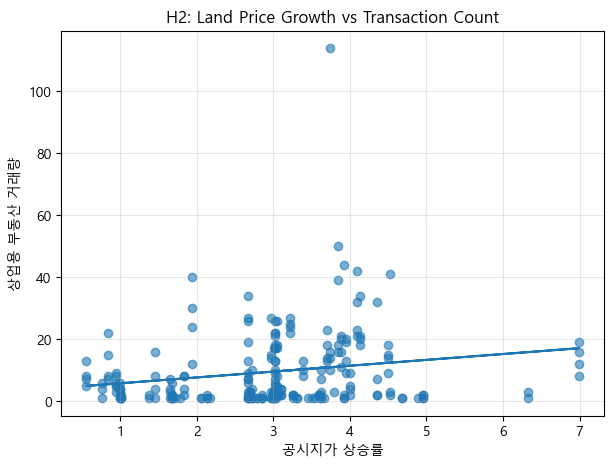

In [59]:
x = h2_data_positive["land_price_growth"]
y = h2_data_positive["transaction_cnt"]

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.6)

# 추세선
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.title("H2: Land Price Growth vs Transaction Count")
plt.xlabel("공시지가 상승률")
plt.ylabel("상업용 부동산 거래량")
plt.grid(True, alpha=0.3)
plt.show()

거래량이 0인건 제외 후 실질적으로 거래가 이루어진 법정동 및 거래량횟수를 나타낸 상관계수 표

거래량이 0인 행을 제외하고 실제 거래가 발생한 법정동·분기만 분석했을 때도 공시지가 상승률과 상업용 부동산 거래량 사이에 유의한 양의 상관관계가 확인되었다. 특히 Spearman rho가 0.2053으로 증가하여, 거래가 발생한 지역에서는 공시지가 상승률이 높을수록 거래량도 상대적으로 많은 경향이 더 뚜렷하게 나타났다.

- H2: 유의함
- 단, 상관강도는 약함
- 대시보드 활용: 보조 지표로 사용 가능

음... 왜 거래량이 0이 많이 나왔는지 확인한 결과 한 법정동에서 상업용 부동산 거래가 매분기마다 발생하지 않을수도 있다고 한다.그래서 상업용 부동산 거래는 특정지역에 몰린경우가 많아 법정동은 거래가 0으로 나타날 가능성이 크다.0값은 법정동별 상업용 거래가 없다는 것이다. 그래서 0이 많이 나타나면은 spearman으로 순위관계를 볼때 위험 할수가 있어 pearson으로 직선관계만 확인

# 3. 가설: 지하철 이용량은 개폐업률, 프랜차이즈 침투율과 관련이 있다.

1. 가설설정
- 귀무가설: 지하철 이용량과 개업률, 폐업률, 프랜차이즈 침투율은 상관관계가 없다.
- 대립가설: 지하철 이용량과 개업률, 폐업률, 프랜차이즈 침투율은 상관관계가 있다.

지하철 이용량이 들어가니 지하철 마스터 테이블 불러오기


In [47]:
subway = pd.read_csv("../data/지하철역_분기_승하차_행정동추가.csv", encoding="utf-8-sig")

print(subway.shape)
print(subway.columns.tolist())
display(subway.head())

(284, 6)
['base_quarter', 'subway_line', 'station_nm', '행정동', 'subway_board_cnt', 'subway_alight_cnt']


,base_quarter,subway_line,station_nm,행정동,subway_board_cnt,subway_alight_cnt
0,2023Q1,8호선,남위례,복정동,533088,551249
1,2023Q1,8호선,남한산성입구(성남법원.검찰청),단대동,1161235,1053034
2,2023Q1,8호선,단대오거리,단대동,1030034,991383
3,2023Q1,8호선,모란,성남동,427255,345384
4,2023Q1,8호선,복정,복정동,777372,657178


In [48]:
# 행정동 및 분기 단위로 지하철 이용량 집계
subway["subway_total_usage"] = subway["subway_board_cnt"] + subway["subway_alight_cnt"]
subway_agg = subway.groupby(
    ["행정동", "base_quarter"],
    as_index=False
).agg(
    subway_board_cnt=("subway_board_cnt", "sum"),
    subway_alight_cnt=("subway_alight_cnt", "sum"),
    subway_total_usage=("subway_total_usage", "sum"),
    subway_station_cnt=("station_nm", "nunique")
)

subway_agg = subway_agg.rename(columns={"행정동": "adm_dong_nm"})

display(subway_agg.head())
print(subway_agg.shape)

,adm_dong_nm,base_quarter,subway_board_cnt,subway_alight_cnt,subway_total_usage,subway_station_cnt
0,구미1동,2023Q1,2251742,2161611,4413353,2
1,구미1동,2023Q2,2303901,2220137,4524038,2
2,구미1동,2023Q3,2188131,2110266,4298397,2
3,구미1동,2023Q4,2305612,2222072,4527684,2
4,구미1동,2024Q1,2293668,2204340,4498008,2


(192, 6)


행정동 및 분기 단위로 cnt값이 집계 된것을 볼 수 있다.

In [49]:
# 이값을 main 컬럼에 있는 개폐업률, 프랜차이즈 침투율과 합치기
main_subway = main.merge(
    subway_agg,
    on=["adm_dong_nm", "base_quarter"],
    how="left"
)

print(main_subway.shape)
display(main_subway.head())

(600, 47)


,base_quarter,year,quarter,adm_dong_cd,adm_dong_nm,gu,floating_pop,purpose_0_ratio,purpose_1_ratio,purpose_2_ratio,...,industry_diversity_H,survival_rate_1y,bus_board_cnt,bus_alight_cnt,전입_소득수준_가중평균,전출_소득수준_가중평균,subway_board_cnt,subway_alight_cnt,subway_total_usage,subway_station_cnt
0,2023Q1,2023,1,41131510,신흥1동,수정구,781803.43,0.459359,0.073425,0.002433,...,3.511952,NaN,383269.0,368664.0,3188.370885,3252.77624,443491.0,463235.0,906726.0,1.0
1,2023Q2,2023,2,41131510,신흥1동,수정구,808998.65,0.483425,0.076062,0.004197,...,3.494871,NaN,405702.0,386649.0,3188.370885,3252.77624,459727.0,482111.0,941838.0,1.0
2,2023Q3,2023,3,41131510,신흥1동,수정구,807881.77,0.487323,0.074089,0.003615,...,3.500230,NaN,416726.0,400858.0,3188.370885,3252.77624,443162.0,466437.0,909599.0,1.0
3,2023Q4,2023,4,41131510,신흥1동,수정구,860145.94,0.482244,0.072668,0.004490,...,3.480380,NaN,423823.0,406845.0,3188.370885,3252.77624,455789.0,478357.0,934146.0,1.0
4,2024Q1,2024,1,41131510,신흥1동,수정구,779105.37,0.493551,0.069158,0.003135,...,3.488654,72.534143,401542.0,392547.0,3188.370885,3252.77624,456298.0,472687.0,928985.0,1.0


지하철역이 없는 동은 nan값 처리됨
지하철역이 없는 동은 이용량도 없는 것이니 nan값을 0으로 처리

In [50]:
subway_cols = [
    "subway_board_cnt",
    "subway_alight_cnt",
    "subway_total_usage",
    "subway_station_cnt"
]

main_subway[subway_cols] = main_subway[subway_cols].fillna(0)

In [51]:
main_subway.head()

,base_quarter,year,quarter,adm_dong_cd,adm_dong_nm,gu,floating_pop,purpose_0_ratio,purpose_1_ratio,purpose_2_ratio,...,industry_diversity_H,survival_rate_1y,bus_board_cnt,bus_alight_cnt,전입_소득수준_가중평균,전출_소득수준_가중평균,subway_board_cnt,subway_alight_cnt,subway_total_usage,subway_station_cnt
0,2023Q1,2023,1,41131510,신흥1동,수정구,781803.43,0.459359,0.073425,0.002433,...,3.511952,NaN,383269.0,368664.0,3188.370885,3252.77624,443491.0,463235.0,906726.0,1.0
1,2023Q2,2023,2,41131510,신흥1동,수정구,808998.65,0.483425,0.076062,0.004197,...,3.494871,NaN,405702.0,386649.0,3188.370885,3252.77624,459727.0,482111.0,941838.0,1.0
2,2023Q3,2023,3,41131510,신흥1동,수정구,807881.77,0.487323,0.074089,0.003615,...,3.500230,NaN,416726.0,400858.0,3188.370885,3252.77624,443162.0,466437.0,909599.0,1.0
3,2023Q4,2023,4,41131510,신흥1동,수정구,860145.94,0.482244,0.072668,0.004490,...,3.480380,NaN,423823.0,406845.0,3188.370885,3252.77624,455789.0,478357.0,934146.0,1.0
4,2024Q1,2024,1,41131510,신흥1동,수정구,779105.37,0.493551,0.069158,0.003135,...,3.488654,72.534143,401542.0,392547.0,3188.370885,3252.77624,456298.0,472687.0,928985.0,1.0


In [ ]:
h3_tests = [corr_test(
        main_subway,
        x_col="subway_total_usage",
        y_col="open_rate",
        hypothesis="H3-1 지하철 이용량은 개업률과 관련이 있다",
        alternative="two-sided"
    ),
    corr_test(
        main_subway,
        x_col="subway_total_usage",
        y_col="close_rate",
        hypothesis="H3-2 지하철 이용량은 폐업률과 관련이 있다",
        alternative="two-sided"
    ),
    corr_test(
        main_subway,
        x_col="subway_total_usage",
        y_col="franchise_ratio",
        hypothesis="H3-3 지하철 이용량은 프랜차이즈 침투율과 관련이 있다",
        alternative="two-sided"
    )
]

h3_result_df = pd.DataFrame(h3_tests)
display(h3_result_df)

,가설,X변수,Y변수,표본수,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,판정
0,H3-1 지하철 이용량은 개업률과 관련이 있다,subway_total_usage,open_rate,600,0.0997,0.0146,0.0997,0.0145,유의함
1,H3-2 지하철 이용량은 폐업률과 관련이 있다,subway_total_usage,close_rate,600,-0.0347,0.3961,0.0104,0.8002,유의하지 않음
2,H3-3 지하철 이용량은 프랜차이즈 침투율과 관련이 있다,subway_total_usage,franchise_ratio,600,0.4281,0.0000,0.1465,0.0003,유의함


첫 번째로, 지하철 이용량과 개업률은 통계적으로 유의한 관계가 확인되었다. 다만 상관계수가 약 0.10 수준으로 매우 낮기 때문에, 실질적으로는 매우 약한 양의 상관관계로 해석하는 것이 적절하다. 즉, 지하철 이용량이 많은 지역에서 개업률이 약간 높게 나타나는 경향은 있으나, 강한 관계라고 보기는 어렵다.

두 번째로, 지하철 이용량과 폐업률은 유의한 관계가 확인되지 않았다. 따라서 현재 데이터만으로는 지하철 이용량이 많다고 해서 폐업률이 높거나 낮다고 판단하기 어렵다.현재 데이터만으로는 관계가 있다고 볼 충분한 증거가 없다

세 번째로, 지하철 이용량과 프랜차이즈 침투율은 통계적으로 유의한 관계가 확인되었다. Pearson 상관계수는 0.4281로 나타나, 선형관계 기준에서는 지하철 이용량이 많을수록 프랜차이즈 침투율도 증가하는 경향이 있다. 그러나 Spearman 상관계수는 0.1465로 약하게 나타났기 때문에, 지하철 이용량 순위가 높은 동이 항상 프랜차이즈 침투율 순위도 높은 것은 아니라고 볼 수 있다.

따라서 H3는 전체적으로 부분적으로 지지된다고 정리할 수 있다. 지하철 이용량은 개업률과 프랜차이즈 침투율과는 관련성이 일부 확인되었지만, 폐업률과는 유의한 관계가 확인되지 않았다.

p-value 작음
→ 우연히 나왔을 가능성이 낮음
→ 귀무가설 기각
→ 관계가 있다고 볼 근거 있음

p-value 큼
→ 우연히 나왔을 가능성이 높음
→ 귀무가설 기각 못함
→ 관계가 있다고 볼 근거 부족

| 검정 방법         | 변수 타입             | 보는 것          | 프로젝트 예시                   |
| ------------- | ----------------- | ------------- | ------------------------- |
| Pearson       | 수치형 × 수치형         | 선형 상관관계       | 공시지가 상승률 ↔ 프랜차이즈 침투율      |
| Spearman      | 수치형/순위형 × 수치형/순위형 | 순위 상관관계       | 지하철 이용량 순위 ↔ 프랜차이즈 침투율 순위 |
| Kendall’s tau | 순위형/수치형 × 순위형/수치형 | 순위쌍 일치 관계     | 표본 작을 때 순위 관계 보조 확인       |
| t-test        | 2집단 범주형 × 수치형     | 두 집단 평균 차이    | 역세권/비역세권의 개업률 차이          |
| ANOVA         | 3집단 이상 범주형 × 수치형  | 여러 집단 평균 차이   | 위험등급 고/중/저별 폐업률 차이        |
| 카이제곱          | 범주형 × 범주형         | 두 범주형 변수의 관련성 | 역세권 여부 × 고위험지역 여부         |


# 4. 가설: 외부유입 비율이 높은 행정동일수록 부동산 거래량이 많을 것이다.

1. 가설설정
- 귀무가설: 외부유입 비율과 상업용 부동산 거래량은 상관관계가 없다.
- 대립가설: 외부유입 비율이 높을수록 상업용 부동산 거래량이 많아지는 상관관계가 있다.

모두 수치형이므로 상관관계로 pearson spearman으로 2개 분석
부동산 거래량 들어간 부분은 0이 많으므로 특정 지역에 몰릴 수 있으므로 최종 해석은 spearman 중심으로

In [60]:
# 외부유입 비율 만들기
main["external_inflow_ratio"] = main["external_inflow"] / main["floating_pop"]

# 무한대/결측 처리
main["external_inflow_ratio"] = main["external_inflow_ratio"].replace([np.inf, -np.inf], np.nan)

In [ ]:
# 부동산 거래량은 법정동으로 되어 있어 행정동기준으로 잡힌 외부유입을 법정동으로 매핑
def make_legal_key(x):
    x = str(x)
    return re.sub(r"(.+)\d+동$", r"\1동", x)

main["legal_key"] = main["adm_dong_nm"].apply(make_legal_key)

main[["adm_dong_nm", "legal_key"]].drop_duplicates().head(30)

,adm_dong_nm,legal_key
0,신흥1동,신흥동
12,신흥2동,신흥동
24,신흥3동,신흥동
36,태평1동,태평동
48,태평2동,태평동
60,태평3동,태평동
72,태평4동,태평동
84,수진1동,수진동
96,수진2동,수진동
108,단대동,단대동


In [62]:
merged_1 = main.merge(
    legal_q[[
        "gu",
        "legal_dong_nm",
        "base_quarter",
        "transaction_cnt"
    ]],
    left_on=["gu", "legal_key", "base_quarter"],
    right_on=["gu", "legal_dong_nm", "base_quarter"],
    how="inner"
)

print("병합 후 행 수:", len(merged_1))
display(merged_1.head())

병합 후 행 수: 588


,base_quarter,year,quarter,adm_dong_cd,adm_dong_nm,gu,floating_pop,purpose_0_ratio,purpose_1_ratio,purpose_2_ratio,...,industry_diversity_H,survival_rate_1y,bus_board_cnt,bus_alight_cnt,전입_소득수준_가중평균,전출_소득수준_가중평균,external_inflow_ratio,legal_key,legal_dong_nm,transaction_cnt
0,2023Q1,2023,1,41131510,신흥1동,수정구,781803.43,0.459359,0.073425,0.002433,...,3.511952,NaN,383269.0,368664.0,3188.370885,3252.77624,0.185027,신흥동,신흥동,2
1,2023Q2,2023,2,41131510,신흥1동,수정구,808998.65,0.483425,0.076062,0.004197,...,3.494871,NaN,405702.0,386649.0,3188.370885,3252.77624,0.176825,신흥동,신흥동,5
2,2023Q3,2023,3,41131510,신흥1동,수정구,807881.77,0.487323,0.074089,0.003615,...,3.500230,NaN,416726.0,400858.0,3188.370885,3252.77624,0.176573,신흥동,신흥동,3
3,2023Q4,2023,4,41131510,신흥1동,수정구,860145.94,0.482244,0.072668,0.004490,...,3.480380,NaN,423823.0,406845.0,3188.370885,3252.77624,0.179537,신흥동,신흥동,4
4,2024Q1,2024,1,41131510,신흥1동,수정구,779105.37,0.493551,0.069158,0.003135,...,3.488654,72.534143,401542.0,392547.0,3188.370885,3252.77624,0.174966,신흥동,신흥동,4


In [ ]:
# 분석 테이블 생성
h4_1_data = merged_1[[
    "gu",
    "adm_dong_nm",
    "legal_key",
    "base_quarter",
    "external_inflow_ratio",
    "transaction_cnt"
]].dropna()

print("분석 가능 행 수:", len(h4_1_data))
display(h4_1_data.head())

분석 가능 행 수: 588


,gu,adm_dong_nm,legal_key,base_quarter,external_inflow_ratio,transaction_cnt
0,수정구,신흥1동,신흥동,2023Q1,0.185027,2
1,수정구,신흥1동,신흥동,2023Q2,0.176825,5
2,수정구,신흥1동,신흥동,2023Q3,0.176573,3
3,수정구,신흥1동,신흥동,2023Q4,0.179537,4
4,수정구,신흥1동,신흥동,2024Q1,0.174966,4


In [64]:
# 분석 테이블 생성 후 상관검정 확인
h4_1_result = corr_test(
    h4_1_data,
    x_col="external_inflow_ratio",
    y_col="transaction_cnt",
    hypothesis="외부유입 비율이 높은 행정동일수록 부동산 거래량이 많을 것이다",
    alternative="greater"
)

h4_1_result_df = pd.DataFrame([h4_1_result])
display(h4_1_result_df)

,가설,X변수,Y변수,표본수,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,판정
0,외부유입 비율이 높은 행정동일수록 부동산 거래량이 많을 것이다,external_inflow_ratio,transaction_cnt,588,0.1188,0.002,0.1284,0.0009,유의함


분석 결과, Spearman rho는 0.1284, p-value는 0.0009로 나타났다. p-value가 유의수준 0.05보다 작으므로 귀무가설을 기각할 수 있다. 따라서 외부유입 비율이 높은 행정동일수록 상업용 부동산 거래량도 상대적으로 많아지는 통계적으로 유의한 약한 양의 관계가 있다고 해석할 수 있다.
다만 상관계수 크기가 0.1284로 매우 낮기 때문에, 강한 관계라기보다는 부동산 거래량을 설명하는 보조 지표로 활용하는 것이 적절하다.

# 5. 가설: 외부유입이 증가한 행정동일수록 공시지가 상승률이 높을 것이다.

1. 가설설정
- 귀무가설: 외부유입 증가율과 공시지가 상승률은 상관관계가 없다.
- 대립가설: 외부유입 증가율과 공시지가 상승률이 높아지는 상관관계가 있다.

In [65]:
# 분기 정렬
main = main.sort_values(["adm_dong_nm", "base_quarter"])

# 외부유입 증가율 만들기
main["external_inflow_growth"] = main.groupby("adm_dong_nm")["external_inflow"].pct_change()

# 행정동 -> 법정동 매핑키가 없으면 생성
main["legal_key"] = main["adm_dong_nm"].apply(make_legal_key)

# 법정동 분기 마스터와 병합
merged_2 = main.merge(
    legal_q[[
        "gu",
        "legal_dong_nm",
        "base_quarter",
        "land_price_growth"
    ]],
    left_on=["gu", "legal_key", "base_quarter"],
    right_on=["gu", "legal_dong_nm", "base_quarter"],
    how="inner"
)

# 분석 데이터
h4_2_data = merged_2[[
    "gu",
    "adm_dong_nm",
    "legal_key",
    "base_quarter",
    "external_inflow_growth",
    "land_price_growth"
]].replace([np.inf, -np.inf], np.nan).dropna()

print("분석 가능 행 수:", len(h4_2_data))
display(h4_2_data.head())

분석 가능 행 수: 392


,gu,adm_dong_nm,legal_key,base_quarter,external_inflow_growth,land_price_growth
4,수정구,고등동,고등동,2024Q1,-0.071742,3.790412
5,수정구,고등동,고등동,2024Q2,0.094064,3.790412
6,수정구,고등동,고등동,2024Q3,-0.065357,3.790412
7,수정구,고등동,고등동,2024Q4,-0.025484,3.790412
8,수정구,고등동,고등동,2025Q1,0.217763,2.858177


이것도 공시지가 상승률이 들어가므로 법정동으로 매핑

In [66]:
h4_2_result = corr_test(
    h4_2_data,
    x_col="external_inflow_growth",
    y_col="land_price_growth",
    hypothesis="외부유입이 증가한 행정동일수록 공시지가 상승률이 높을 것이다",
    alternative="greater"
)

h4_2_result_df = pd.DataFrame([h4_2_result])
display(h4_2_result_df)

,가설,X변수,Y변수,표본수,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,판정
0,외부유입이 증가한 행정동일수록 공시지가 상승률이 높을 것이다,external_inflow_growth,land_price_growth,392,0.1747,0.0003,0.1989,0.0,유의함


확인 결과 pearson은 0.1747, spearman은 0.1989로 둘 다 약한 상관관계를 보였다. p-value는 각각 0.0003, 0.0이므로 유의수준0.05보다 작아 귀무가설을 기각할 수 있다. 따라서 외부유입이 증가한 행정동일수록 공시지가 상승률도 상대적으로 높게 나타나는 경향을 볼 수 있을 거 같다. 다만 상관계수가 약한 상관관계이므로 보조적인 역할로 해석하는게 좋을 거 같다.

# 6. 평균 체류시간이 긴 행정동일수록 객단가가 높을 것이다.
# 6-1) 평균 체류시간이 긴 행정동일수록 매출액이 높을 것이다.

6. 가설설정
- 귀무가설: 평균 체류시간과 객단가는 상관관계가 없다. 
- 대립가설: 평균 체류시간이 길수록 객단가가 상관관계가 있다.

6-1) 가설설정
- 귀무가설: 평균 체류시간과 매출액은 상관관계가 없다.
- 대립가설: 평균 체류시간이 길수록 매출액이랑 상관관계가 있다.

컬럼 만든게 있으므로 바로 상관관계 검정

In [71]:
h_stay_sales_tests = [
    corr_test(
        main,
        x_col="stay_time_weighted",
        y_col="sales_amt",
        hypothesis="H6-1 평균 체류시간이 긴 행정동일수록 매출액이 높을 것이다",
        alternative="greater"
    ),
    corr_test(
        main,
        x_col="stay_time_weighted",
        y_col="avg_ticket",
        hypothesis="H6-2 평균 체류시간이 긴 행정동일수록 객단가가 높을 것이다",
        alternative="greater"
    )
]

h_stay_sales_result_df = pd.DataFrame(h_stay_sales_tests)
display(h_stay_sales_result_df)

,가설,X변수,Y변수,표본수,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,판정
0,H6-1 평균 체류시간이 긴 행정동일수록 매출액이 높을 것이다,stay_time_weighted,sales_amt,600,-0.0935,0.989,-0.1854,1.0000,유의하지 않음
1,H6-2 평균 체류시간이 긴 행정동일수록 객단가가 높을 것이다,stay_time_weighted,avg_ticket,600,0.1841,0.000,-0.1482,0.9999,유의하지 않음


검정 결과 평균 체류시간과 매출액, 객단가 간의 관계를 본 결과 spearman에서 매출액 객단가가 음의 상관계수로 나타났고 p-value도 0.05보다 크게 나타나 귀무가설 기각하지 못하였다. 그래서 현재 데이터에서는 평균 체류시간이 긴 행정동일수록 매출액이나 객단가가 높다고 볼 수 있는 통계적 근거는 확인되지 않았다.

그래서 결론은 체류시간이 길다고 해서 매출액, 객단가가 높아진다고 보기 어렵다. 순위기준에서는 약한 음의 방향이 보이지만 우리가 설정한 양의 방향가설을 지지하지 않는걸로 보인다.
- 체류형 상권 특성 참고 지표로만 사용 △ 체류시간은 젤뒤로 미루는 쪽으로

# 7. 버스 승하차가 높은 행정동일수록 유동인구가 많을 것이다.

# 7-1) 버스 승하차가 높은 행정동일수록 외부유입이 많을 것이다.

7. 가설설정
- 귀무가설: 버스 승하차와 유동인구는 상관관계가 없다.
- 대립가설: 버스 승하차가 많을수록 유동인구가 많아지는 상관관계가 있다.

7-1) 가설설정
- 귀무가설: 버스 승하차와 외부유입은 상관관계가 없다.
- 대립가설: 버스 승하차가 많을수록 외부유입이 많아지는 상관관계가 있다.

In [74]:
print([col for col in main.columns if "bus" in col or "floating" in col or "external" in col])

['floating_pop', 'external_inflow', 'bus_board_cnt', 'bus_alight_cnt', 'external_inflow_ratio', 'external_inflow_growth', 'bus_total_usage']


In [ ]:
main["bus_total_usage"] = main["bus_board_cnt"] + main["bus_alight_cnt"]

h_bus_tests = [
    corr_test(
        main,
        x_col="bus_total_usage",
        y_col="floating_pop",
        hypothesis="H7-1 버스 승하차가 높은 행정동일수록 유동인구가 많을 것이다",
        alternative="greater"
    ),
    corr_test(
        main,
        x_col="bus_total_usage",
        y_col="external_inflow",
        hypothesis="H7-2 버스 승하차가 높은 행정동일수록 외부유입이 많을 것이다",
        alternative="greater"
    )
]

h_bus_result_df = pd.DataFrame(h_bus_tests)

print("검정 완료")
display(h_bus_result_df)

검정 완료


,가설,X변수,Y변수,표본수,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,판정
0,H6-1 버스 승하차가 높은 행정동일수록 유동인구가 많을 것이다,bus_total_usage,floating_pop,600,0.7665,0.0,0.6548,0.0,유의함
1,H6-2 버스 승하차가 높은 행정동일수록 외부유입이 많을 것이다,bus_total_usage,external_inflow,600,0.6746,0.0,0.6374,0.0,유의함


오... 버스 승하차와 유동인구 사이에는 통계적으로 강한 상관관게가 있는것으로 확인되었다. 즉 버스 승하차가 많은 행정동일수록 유동인구도 많은 경향이 뚜렷하게 보인다. 그리고 버스 승하차랑 외부유입도 통계적으로 강한 상관관계가 나타났다 즉 이것도 버스 이용량이 많은 행정동일수록 외부에서 유입되는 인구도 많다는 경향으로 보인다.

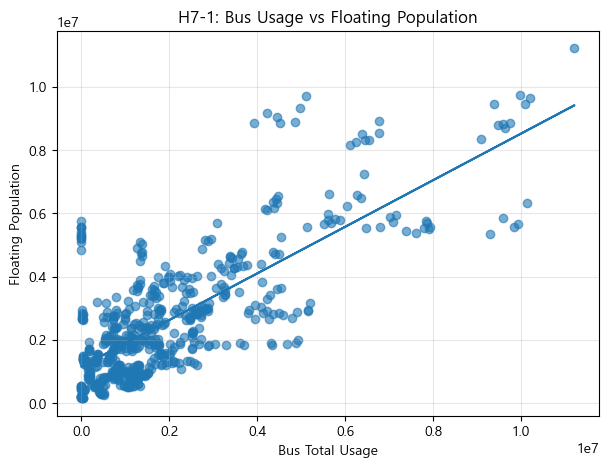

In [78]:
# 그래프로 확인 해보기
x = main["bus_total_usage"]
y = main["floating_pop"]

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.6)

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.title("H7-1: Bus Usage vs Floating Population")
plt.xlabel("Bus Total Usage")
plt.ylabel("Floating Population")
plt.grid(True, alpha=0.3)
plt.show()

그래프로도 확실히 선형관계가 우상향으로 보인다 완전 일직선은 아니지만 이걸로 강한 상관관계라는 것이 확인됨.

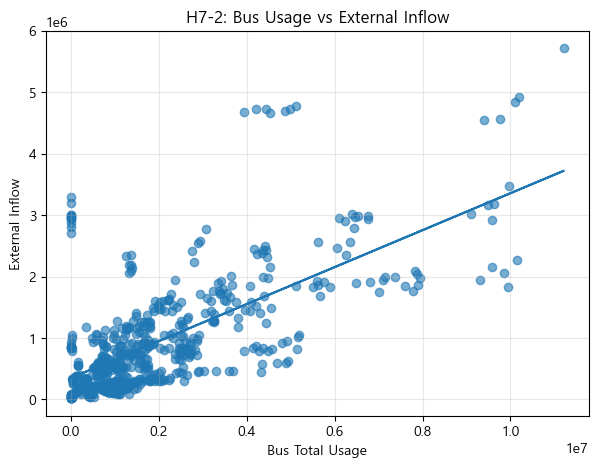

In [79]:
x = main["bus_total_usage"]
y = main["external_inflow"]

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.6)

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.title("H7-2: Bus Usage vs External Inflow")
plt.xlabel("Bus Total Usage")
plt.ylabel("External Inflow")
plt.grid(True, alpha=0.3)
plt.show()

외부유입은 유동인구보다 점들의 분산이 크지만, 전체적으로는 버스 승하차량이 증가할수록 외부유입도 증가하는 우상향 경향이 확인

그래프와 상관분석 결과 모두에서 버스 승하차량은 유동인구 및 외부유입과 강한 양의 관계를 보여, 대시보드에서 교통 접근성과 유동성 지표로 활용하기 적합

# 8. 가설: 유동인구 증가, 외부유입 증가, 체류시간 증가가 동시에 나타나는 행정동은 젠트리피케이션 위험도가 높을 것이다. 

이거는 상관관계가 아니라...... 음...... 어디동이 위험이 높은지를 보는건데....

만약 가설설정을 한다면??
- 귀무가설: 세 지표가 동시에 증가하는 곳은 젠트리피케이션 위험도와 관련이 없다.??
- 대립가설: 세 지표가 동시에 증가하는 곳은 젠트리피케이션 위험도와 관련이 있다.

In [80]:
# 세 지표의 증가율 변수 생성
main = main.sort_values(["adm_dong_nm", "base_quarter"])

main["floating_pop_growth"] = main.groupby("adm_dong_nm")["floating_pop"].pct_change()
main["external_inflow_growth"] = main.groupby("adm_dong_nm")["external_inflow"].pct_change()
main["stay_time_growth"] = main.groupby("adm_dong_nm")["stay_time_weighted"].pct_change()

In [81]:
main

,base_quarter,year,quarter,adm_dong_cd,adm_dong_nm,gu,floating_pop,purpose_0_ratio,purpose_1_ratio,purpose_2_ratio,...,bus_board_cnt,bus_alight_cnt,전입_소득수준_가중평균,전출_소득수준_가중평균,external_inflow_ratio,legal_key,external_inflow_growth,bus_total_usage,floating_pop_growth,stay_time_growth
180,2023Q1,2023,1,41131640,고등동,수정구,1447547.30,0.340732,0.175089,0.007172,...,317296.0,314401.0,4581.570391,4762.323152,0.400527,고등동,NaN,631697.0,NaN,NaN
181,2023Q2,2023,2,41131640,고등동,수정구,1626590.55,0.345616,0.152986,0.010539,...,364517.0,363309.0,4581.570391,4762.323152,0.403924,고등동,0.133219,727826.0,0.123687,-0.032642
182,2023Q3,2023,3,41131640,고등동,수정구,1705796.17,0.339101,0.153879,0.009650,...,355561.0,356225.0,4581.570391,4762.323152,0.411433,고등동,0.068188,711786.0,0.048694,0.002498
183,2023Q4,2023,4,41131640,고등동,수정구,1668678.38,0.339226,0.149429,0.010227,...,360062.0,364606.0,4581.570391,4762.323152,0.408237,고등동,-0.029357,724668.0,-0.021760,-0.008871
184,2024Q1,2024,1,41131640,고등동,수정구,1570351.01,0.347402,0.155271,0.007091,...,339657.0,340461.0,4581.570391,4762.323152,0.402678,고등동,-0.071742,680118.0,-0.058925,0.029617
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,2024Q4,2024,4,41133660,하대원동,중원구,1739245.19,0.570404,0.115710,0.028048,...,616687.0,609415.0,3710.388210,3648.919569,0.220176,하대원동,-0.002212,1226102.0,0.013359,-0.004448
320,2025Q1,2025,1,41133660,하대원동,중원구,1632672.65,0.581344,0.117683,0.019639,...,575786.0,569611.0,3710.388210,3648.919569,0.299996,하대원동,0.279036,1145397.0,-0.061275,0.088932
321,2025Q2,2025,2,41133660,하대원동,중원구,1748738.64,0.578051,0.118059,0.026809,...,641070.0,625465.0,3710.388210,3648.919569,0.305078,하대원동,0.089234,1266535.0,0.071090,-0.024651
322,2025Q3,2025,3,41133660,하대원동,중원구,1765051.85,0.567982,0.126301,0.022610,...,570823.0,565539.0,3710.388210,3648.919569,0.303199,하대원동,0.003113,1136362.0,0.009329,0.004460


In [82]:
# 그리고 세 지표가 동시에 증가한 행 생성
risk_base = main.copy()

risk_base["triple_growth_signal"] = (
    (risk_base["floating_pop_growth"] > 0) &
    (risk_base["external_inflow_growth"] > 0) &
    (risk_base["stay_time_growth"] > 0)
).astype(int)

print("동시 증가 발생 행 수:", risk_base["triple_growth_signal"].sum())
print("전체 행 수:", len(risk_base))

동시 증가 발생 행 수: 71
전체 행 수: 600


In [83]:
# 행정동별 위험 신호 횟수가 어디에 많은지
risk_summary = risk_base.groupby(
    ["gu", "adm_dong_nm"],
    as_index=False
).agg(
    signal_count=("triple_growth_signal", "sum"),
    avg_floating_growth=("floating_pop_growth", "mean"),
    avg_external_growth=("external_inflow_growth", "mean"),
    avg_stay_growth=("stay_time_growth", "mean"),
    avg_franchise_ratio=("franchise_ratio", "mean"),
    avg_open_rate=("open_rate", "mean"),
    avg_close_rate=("close_rate", "mean")
)

risk_summary = risk_summary.sort_values(
    "signal_count",
    ascending=False
)

display(risk_summary.head(20))

,gu,adm_dong_nm,signal_count,avg_floating_growth,avg_external_growth,avg_stay_growth,avg_franchise_ratio,avg_open_rate,avg_close_rate
28,수정구,시흥동,7,0.036063,0.057406,0.020886,8.195751,1.717571,1.019952
9,분당구,수내2동,4,0.067273,0.155675,0.015219,3.100418,1.378941,1.080700
27,수정구,수진2동,4,0.021408,0.041259,0.006600,4.719539,1.116069,1.127758
30,수정구,신흥1동,3,-0.002966,0.044869,0.012791,5.113475,1.333285,1.353434
4,분당구,분당동,3,0.011589,0.025714,0.004279,7.320291,1.045586,0.888191
5,분당구,삼평동,3,0.010837,0.007315,-0.001386,8.769799,1.301223,1.073614
48,중원구,중앙동,3,0.016881,0.048210,0.009937,4.308715,1.067602,1.019872
1,분당구,구미동,2,0.006219,0.009094,0.004016,7.665063,1.225613,1.087950
2,분당구,금곡동,2,0.012852,0.018767,0.004516,5.426654,1.144423,1.037751
39,중원구,금광1동,2,0.007960,0.031861,0.009636,6.394742,1.872775,1.122234


In [84]:
risk_base["floating_rank"] = risk_base["floating_pop_growth"].rank(pct=True)
risk_base["external_rank"] = risk_base["external_inflow_growth"].rank(pct=True)
risk_base["stay_rank"] = risk_base["stay_time_growth"].rank(pct=True)

risk_base["growth_pressure_score"] = risk_base[
    ["floating_rank", "external_rank", "stay_rank"]
].mean(axis=1)

In [ ]:
# 행정동별 위험 평균 점수
risk_score_summary = risk_base.groupby(
    ["gu", "adm_dong_nm"],
    as_index=False
).agg(
    signal_count=("triple_growth_signal", "sum"),
    avg_growth_pressure_score=("growth_pressure_score", "mean"),
    avg_floating_growth=("floating_pop_growth", "mean"),
    avg_external_growth=("external_inflow_growth", "mean"),
    avg_stay_growth=("stay_time_growth", "mean"),
    avg_franchise_ratio=("franchise_ratio", "mean"),
    avg_open_rate=("open_rate", "mean"),
    avg_close_rate=("close_rate", "mean")
)

risk_score_summary = risk_score_summary.sort_values(
    ["signal_count", "avg_growth_pressure_score"],
    ascending=False
)

display(risk_score_summary.head(20))

,gu,adm_dong_nm,signal_count,avg_growth_pressure_score,avg_floating_growth,avg_external_growth,avg_stay_growth,avg_franchise_ratio,avg_open_rate,avg_close_rate
28,수정구,시흥동,7,0.659174,0.036063,0.057406,0.020886,8.195751,1.717571,1.019952
27,수정구,수진2동,4,0.550358,0.021408,0.041259,0.006600,4.719539,1.116069,1.127758
9,분당구,수내2동,4,0.481983,0.067273,0.155675,0.015219,3.100418,1.378941,1.080700
48,중원구,중앙동,3,0.519614,0.016881,0.048210,0.009937,4.308715,1.067602,1.019872
4,분당구,분당동,3,0.512342,0.011589,0.025714,0.004279,7.320291,1.045586,0.888191
30,수정구,신흥1동,3,0.497576,-0.002966,0.044869,0.012791,5.113475,1.333285,1.353434
5,분당구,삼평동,3,0.473774,0.010837,0.007315,-0.001386,8.769799,1.301223,1.073614
31,수정구,신흥2동,2,0.599890,0.046274,0.059902,0.008394,6.197979,1.505793,1.011923
18,분당구,정자2동,2,0.542424,0.021962,0.055828,0.007685,8.042062,0.929324,0.772573
22,수정구,고등동,2,0.538347,0.024792,0.044341,0.004022,7.842033,1.899530,0.985249


In [86]:
# 상위 위험 후보지가 어디인가??
top_risk_candidates = risk_score_summary.head(10)

display(top_risk_candidates)

,gu,adm_dong_nm,signal_count,avg_growth_pressure_score,avg_floating_growth,avg_external_growth,avg_stay_growth,avg_franchise_ratio,avg_open_rate,avg_close_rate
28,수정구,시흥동,7,0.659174,0.036063,0.057406,0.020886,8.195751,1.717571,1.019952
27,수정구,수진2동,4,0.550358,0.021408,0.041259,0.006600,4.719539,1.116069,1.127758
9,분당구,수내2동,4,0.481983,0.067273,0.155675,0.015219,3.100418,1.378941,1.080700
48,중원구,중앙동,3,0.519614,0.016881,0.048210,0.009937,4.308715,1.067602,1.019872
4,분당구,분당동,3,0.512342,0.011589,0.025714,0.004279,7.320291,1.045586,0.888191
30,수정구,신흥1동,3,0.497576,-0.002966,0.044869,0.012791,5.113475,1.333285,1.353434
5,분당구,삼평동,3,0.473774,0.010837,0.007315,-0.001386,8.769799,1.301223,1.073614
31,수정구,신흥2동,2,0.599890,0.046274,0.059902,0.008394,6.197979,1.505793,1.011923
18,분당구,정자2동,2,0.542424,0.021962,0.055828,0.007685,8.042062,0.929324,0.772573
22,수정구,고등동,2,0.538347,0.024792,0.044341,0.004022,7.842033,1.899530,0.985249


유동인구 증가율, 외부유입 증가율, 평균 체류시간 증가율이 동시에 양수로 나타나는 경우를 동시 증가 신호로 정의하였다. 이후 행정동별로 해당 신호가 몇 번 발생했는지와 세 증가율의 순위 기반 평균 점수를 계산하여 위험 후보지를 도출

유동인구, 외부유입, 체류시간이 동시에 증가하는 행정동은 외부 방문 수요와 체류형 소비 가능성이 함께 증가하는 지역으로 볼 수 있어, 젠트리피케이션 위험 후보지로 우선 모니터링할 필요가 있다.